In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('Housing_data.csv')

In [3]:
df.shape

(1047, 7)

In [4]:
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0


In [5]:
#### info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       1047 non-null   int64  
 1   LivingArea  1047 non-null   int64  
 2   Bathrooms   1047 non-null   float64
 3   Bedrooms    1047 non-null   int64  
 4   LotSize     1047 non-null   float64
 5   Age         1047 non-null   int64  
 6   Fireplace   1047 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 57.4 KB


In [6]:
### duplicates
df.duplicated().sum()

np.int64(12)

In [7]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#### Misssing values
df.isnull().sum()

Price         0
LivingArea    0
Bathrooms     0
Bedrooms      0
LotSize       0
Age           0
Fireplace     0
dtype: int64

In [10]:
#### outlier check
target= df[['Price']]
features= df.drop(columns=['Price'])
features.head()

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,1629,1.0,3,0.76,180,0
1,1344,2.0,3,0.92,13,0
2,822,1.0,2,0.56,173,0
3,1540,1.0,2,0.04,115,0
4,1320,1.0,3,0.17,90,0


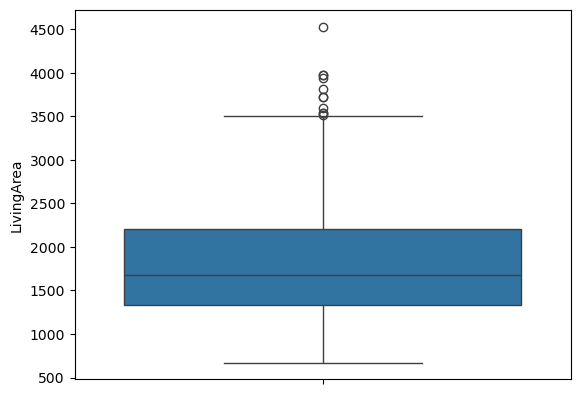

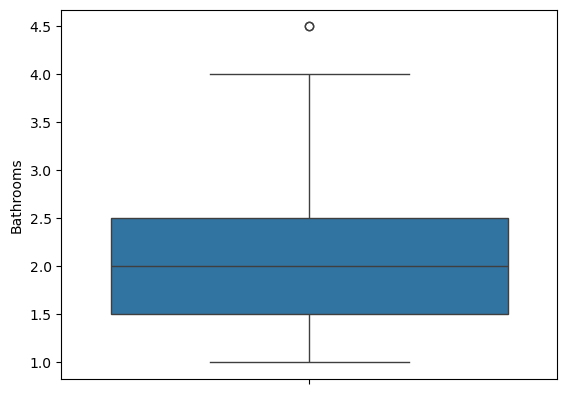

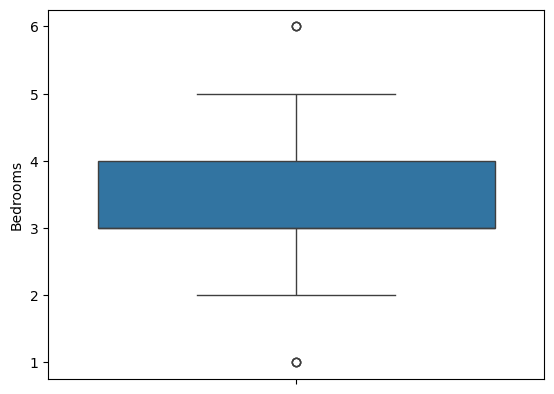

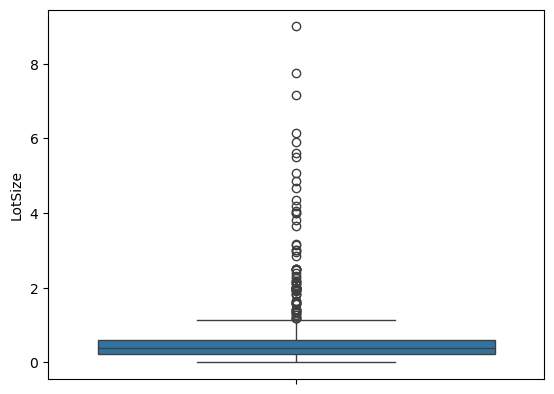

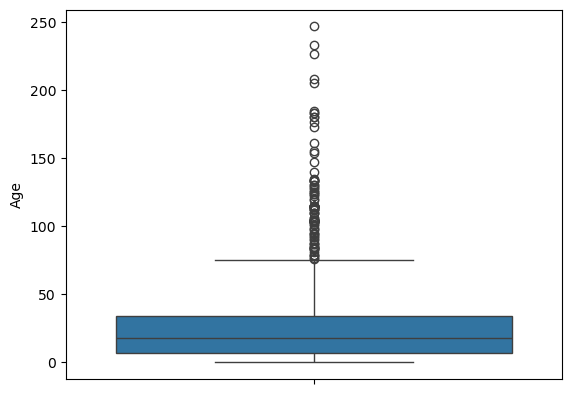

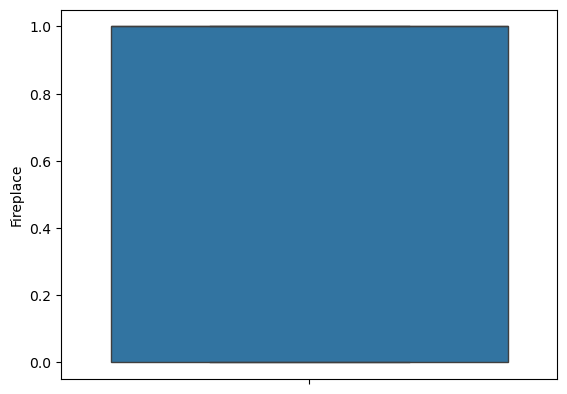

In [11]:
for col in features.columns:
    sns.boxplot(data=features,y=col)
    plt.show()

In [12]:
#### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

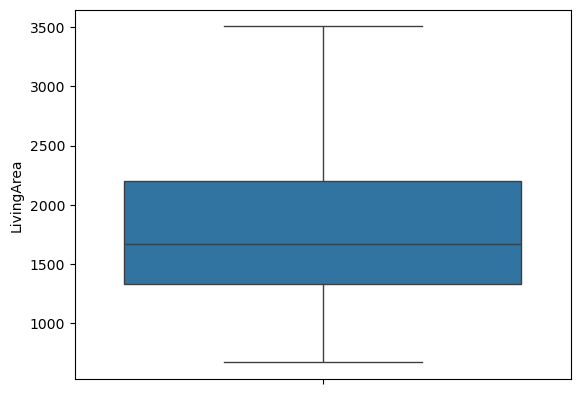

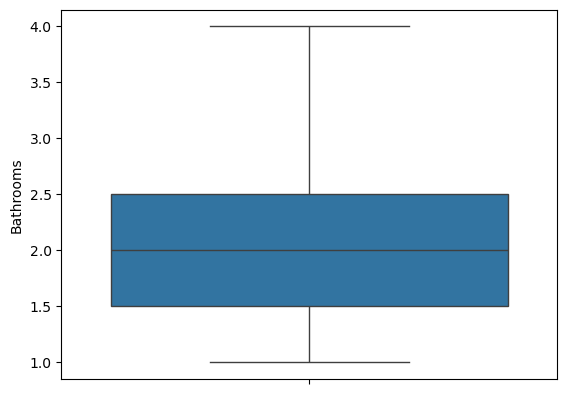

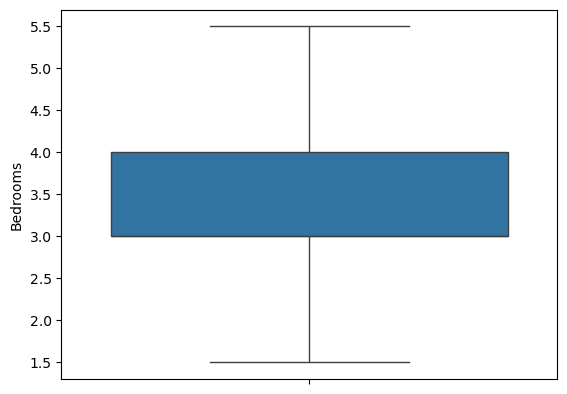

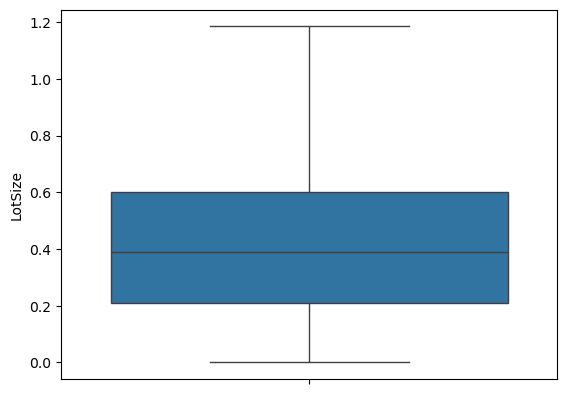

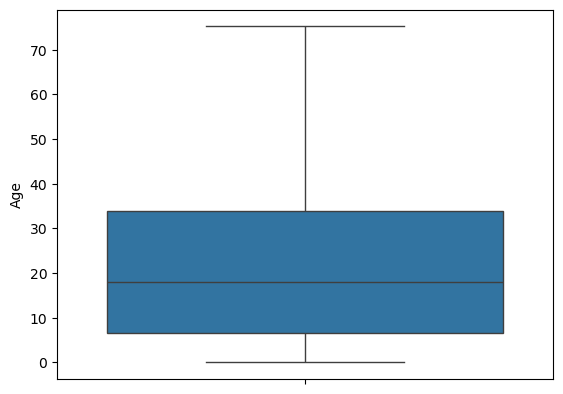

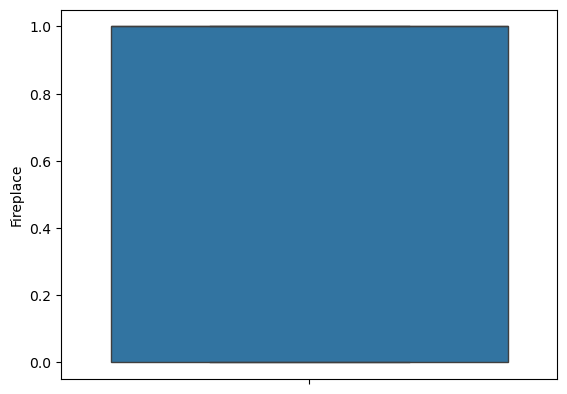

In [13]:
for col in features.columns:
    sns.boxplot(data=features,y=col)
    plt.show()

In [14]:
df1= pd.concat([features,target],axis=1)
df1.head()

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace,Price
0,1629.0,1.0,3.0,0.76,75.25,0,16858
1,1344.0,2.0,3.0,0.92,13.00,0,26049
2,822.0,1.0,2.0,0.56,75.25,0,26130
3,1540.0,1.0,2.0,0.04,75.25,0,31113
4,1320.0,1.0,3.0,0.17,75.25,0,40932


<Axes: >

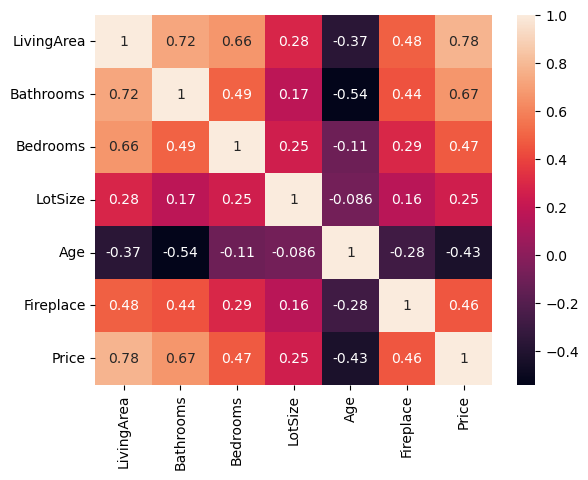

In [15]:
#### correlation
corr=df1.corr()
sns.heatmap(corr,annot=True)

In [16]:
from sklearn.feature_selection import f_regression

<Axes: >

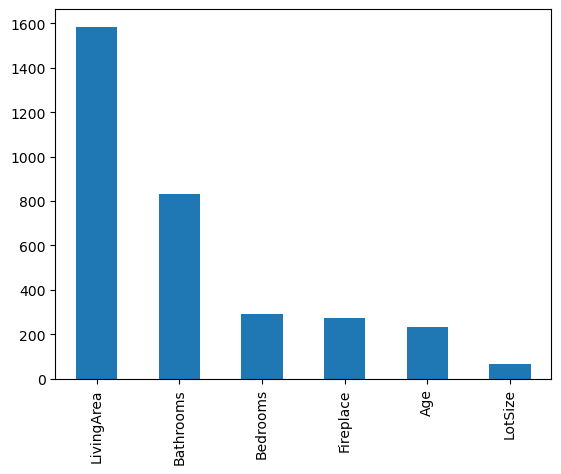

In [17]:
f_reg=f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')

In [18]:
features.columns

Index(['LivingArea', 'Bathrooms', 'Bedrooms', 'LotSize', 'Age', 'Fireplace'], dtype='object')

In [19]:
####  Check Multicolinearity
#### Variance Inflation Factor ( VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
features.head()

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,1629.0,1.0,3.0,0.76,75.25,0
1,1344.0,2.0,3.0,0.92,13.00,0
2,822.0,1.0,2.0,0.56,75.25,0
3,1540.0,1.0,2.0,0.04,75.25,0
4,1320.0,1.0,3.0,0.17,75.25,0


In [21]:
features.values

array([[1.629e+03, 1.000e+00, 3.000e+00, 7.600e-01, 7.525e+01, 0.000e+00],
       [1.344e+03, 2.000e+00, 3.000e+00, 9.200e-01, 1.300e+01, 0.000e+00],
       [8.220e+02, 1.000e+00, 2.000e+00, 5.600e-01, 7.525e+01, 0.000e+00],
       ...,
       [3.361e+03, 3.500e+00, 4.000e+00, 7.100e-01, 1.000e+00, 1.000e+00],
       [3.250e+03, 2.500e+00, 3.000e+00, 5.300e-01, 2.300e+01, 1.000e+00],
       [3.467e+03, 2.500e+00, 4.000e+00, 3.400e-01, 3.000e+00, 1.000e+00]],
      shape=(1035, 6))

In [22]:
features.columns

Index(['LivingArea', 'Bathrooms', 'Bedrooms', 'LotSize', 'Age', 'Fireplace'], dtype='object')

In [23]:
for i in range(len(features.columns)):
    print(i)

0
1
2
3
4
5


In [24]:
vif= pd.DataFrame()
vif['Features']= features.columns
vif['VIF_Scores']= [variance_inflation_factor(features.values,i) for i in range(len(features.columns))]

In [25]:
vif

,Features,VIF_Scores
0,LivingArea,28.393716
1,Bathrooms,21.617158
2,Bedrooms,29.100456
3,LotSize,3.345417
4,Age,2.471556
5,Fireplace,3.304989


In [29]:
features.drop(columns =['LotSize'],inplace = True)

KeyError: "['LotSize'] not found in axis"

In [30]:
features.head()

,LivingArea,Bathrooms,Bedrooms,Age,Fireplace
0,1629.0,1.0,3.0,75.25,0
1,1344.0,2.0,3.0,13.00,0
2,822.0,1.0,2.0,75.25,0
3,1540.0,1.0,2.0,75.25,0
4,1320.0,1.0,3.0,75.25,0


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [50]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(828, 5)
(207, 5)
(828, 1)
(207, 1)


In [51]:
x_train.head()

,LivingArea,Bathrooms,Bedrooms,Age,Fireplace
237,1218.0,1.5,3.0,0.00,1
194,1852.0,1.0,4.0,75.25,0
327,1308.0,1.0,3.0,29.00,0
122,912.0,1.5,2.0,20.00,0
789,2147.0,2.5,4.0,9.00,1


In [52]:
from sklearn.preprocessing import StandardScaler
std_sca = StandardScaler()
x_train[['LivingArea','Age']] = std_sca.fit_transform(x_train[['LivingArea','Age']])
x_test[['LivingArea','Age']] = std_sca.transform(x_test[['LivingArea','Age']])

In [53]:
## model building

lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
lin_reg.coef_

array([[43438.82928985, 19283.73922852, -8226.5338234 , -4965.16383183,
        11546.19403808]])

In [55]:
lin_reg.intercept_

array([145804.09578289])

In [56]:
# training validation
y_pred = lin_reg.predict(x_train)
r2_score(y_train,y_pred)

0.6431780605373439

In [64]:
## testing validation
y_pred1= lin_reg.predict(x_test)
r_squared=r2_score(y_test,y_pred1)

In [60]:
lin_reg.predict([[0.3,2,2,0.98,1]])

array([[187630.48886298]])

<Axes: xlabel='Price'>

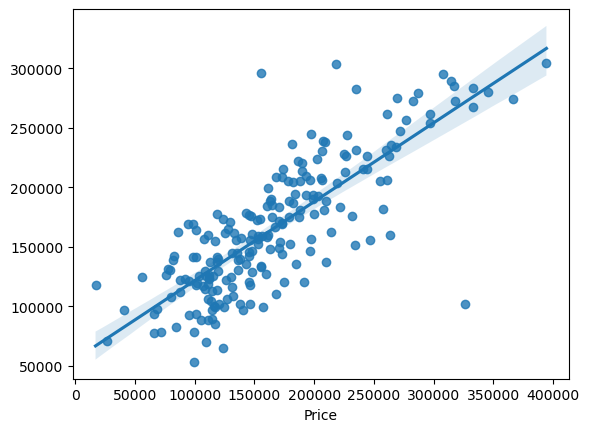

In [61]:
## regression plot
sns.regplot(x=y_test,y = y_pred1)

In [62]:
N=207
k=5

In [65]:
#### Error Metrics
#### adj_rsquared
adj_rsquared= 1-(((1-r_squared)*(N-1))/(N-k-1))
adj_rsquared

0.6333963460450598

In [66]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [68]:
mean_squared_error(y_test,y_pred1)

1613164103.4902415

In [ ]:
mean_absolute